<a href="https://colab.research.google.com/github/Yahsakem1/ml_projects/blob/main/churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import FunctionTransformer,OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy.stats import mannwhitneyu,ttest_ind
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.metrics import roc_auc_score,average_precision_score,f1_score,recall_score,precision_score,classification_report
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier


In [ ]:
data = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


#Задача бинарной классификации
Предсказываем отток пользователей

In [ ]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


#Краткие выводы по начальной сводке
Большое количество категориальных переменных (как их обрабатывать?)

Из числовых одна бинарная (посмотреть соотношение), остальные непрерывные (проверить на выбросы)

Пустых значений вроде бы нет

Из категориальных много бинарных признаков

#Проверим какие категориальные признаки являются бинарными

In [ ]:
categorical_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()
binary_cols = []
multiclass_cols = {}
for col in categorical_cols:
  cnt_unique_value = data[col].nunique()
  if cnt_unique_value == 2:
    binary_cols.append(col)
  else:
    multiclass_cols[col] = cnt_unique_value
print("Список бинарных признаков")
print(binary_cols,len(binary_cols))
print("-"*100)
print("Список мультиклассовых признаков")
print(multiclass_cols,len(multiclass_cols))

Список бинарных признаков
['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn'] 6
----------------------------------------------------------------------------------------------------
Список мультиклассовых признаков
{'customerID': 7043, 'MultipleLines': 3, 'InternetService': 3, 'OnlineSecurity': 3, 'OnlineBackup': 3, 'DeviceProtection': 3, 'TechSupport': 3, 'StreamingTV': 3, 'StreamingMovies': 3, 'Contract': 3, 'PaymentMethod': 4, 'TotalCharges': 6531} 12


Мы имеем 6 бинарных признаков и 11 мультиклассовых (customerID не считаем, просто уникальный ID пользователя, причем пользователя не повторяются в данных, это важно!)

Почему то признак TotalCharges является категориальным, хотя там числа

Проверим TotalCharges

In [ ]:
converted_totalcharges = pd.to_numeric(data["TotalCharges"], errors="coerce")
bad_rows_mask = converted_totalcharges.isna() & data["TotalCharges"].notna()
invalid_values = data.loc[bad_rows_mask, "TotalCharges"].unique()
invalid_values

array([' '], dtype=object)

In [ ]:
data[data["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [ ]:
data[data["TotalCharges"] == " "]["tenure"]

,tenure
488,0
753,0
936,0
1082,0
1340,0
3331,0
3826,0
4380,0
5218,0
6670,0


Пустые значения могут быть из - за того что пользователь начал пользоваться совсем недавно ( меньше месяца), исходя из этого предположения я бы заполнял тем же значением что и в месячной плате, либо нулем.

Выбрал месячную плату

In [ ]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"],errors = "coerce")
data["TotalCharges"] = data["TotalCharges"].fillna(data["MonthlyCharges"])
data["TotalCharges"].dtype

dtype('float64')

In [ ]:
data["TotalCharges"].describe()

,TotalCharges
count,7043.000000
mean,2279.798992
std,2266.730170
min,18.800000
25%,398.550000
50%,1394.550000
75%,3786.600000
max,8684.800000


#Проверим распределения

In [ ]:
churn_count = data["Churn"].value_counts().reset_index()
churn_count["Percentile"] = churn_count["count"]/churn_count["count"].sum()
churn_count

,Churn,count,Percentile
0,No,5174,0.73463
1,Yes,1869,0.26537


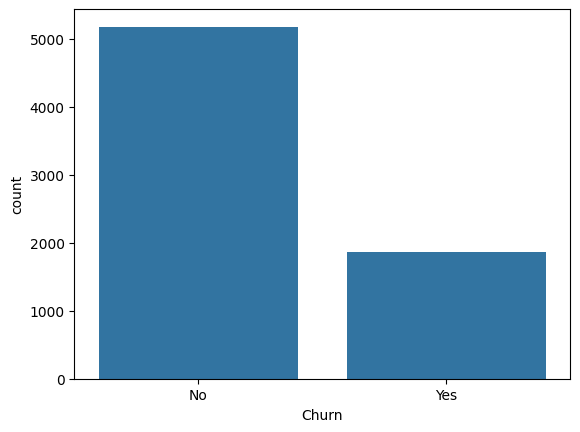

In [ ]:
sns.countplot(data = data,x = "Churn")
plt.show()

Наблюдаем дисбаланс классов

Для решения для logistic regression попробуем SMOTE и EasyEnsemble

Для деревьев просто class_weight

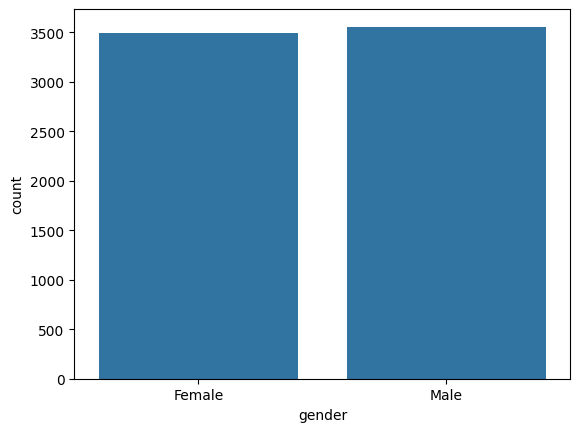

In [ ]:
sns.countplot(data = data,x = "gender")
plt.show()

Почему проверяем распределение по гендеру?

Считаем что распределение мужчин и женщин в данных должно быть одинаковым, если это не так, то необходимо смотреть это статистически что одних больше (например на какой нибудь стройке мужчин намного больше) или ошибка в сборе данных

Построим графики распределния Churn по категориальных признаков

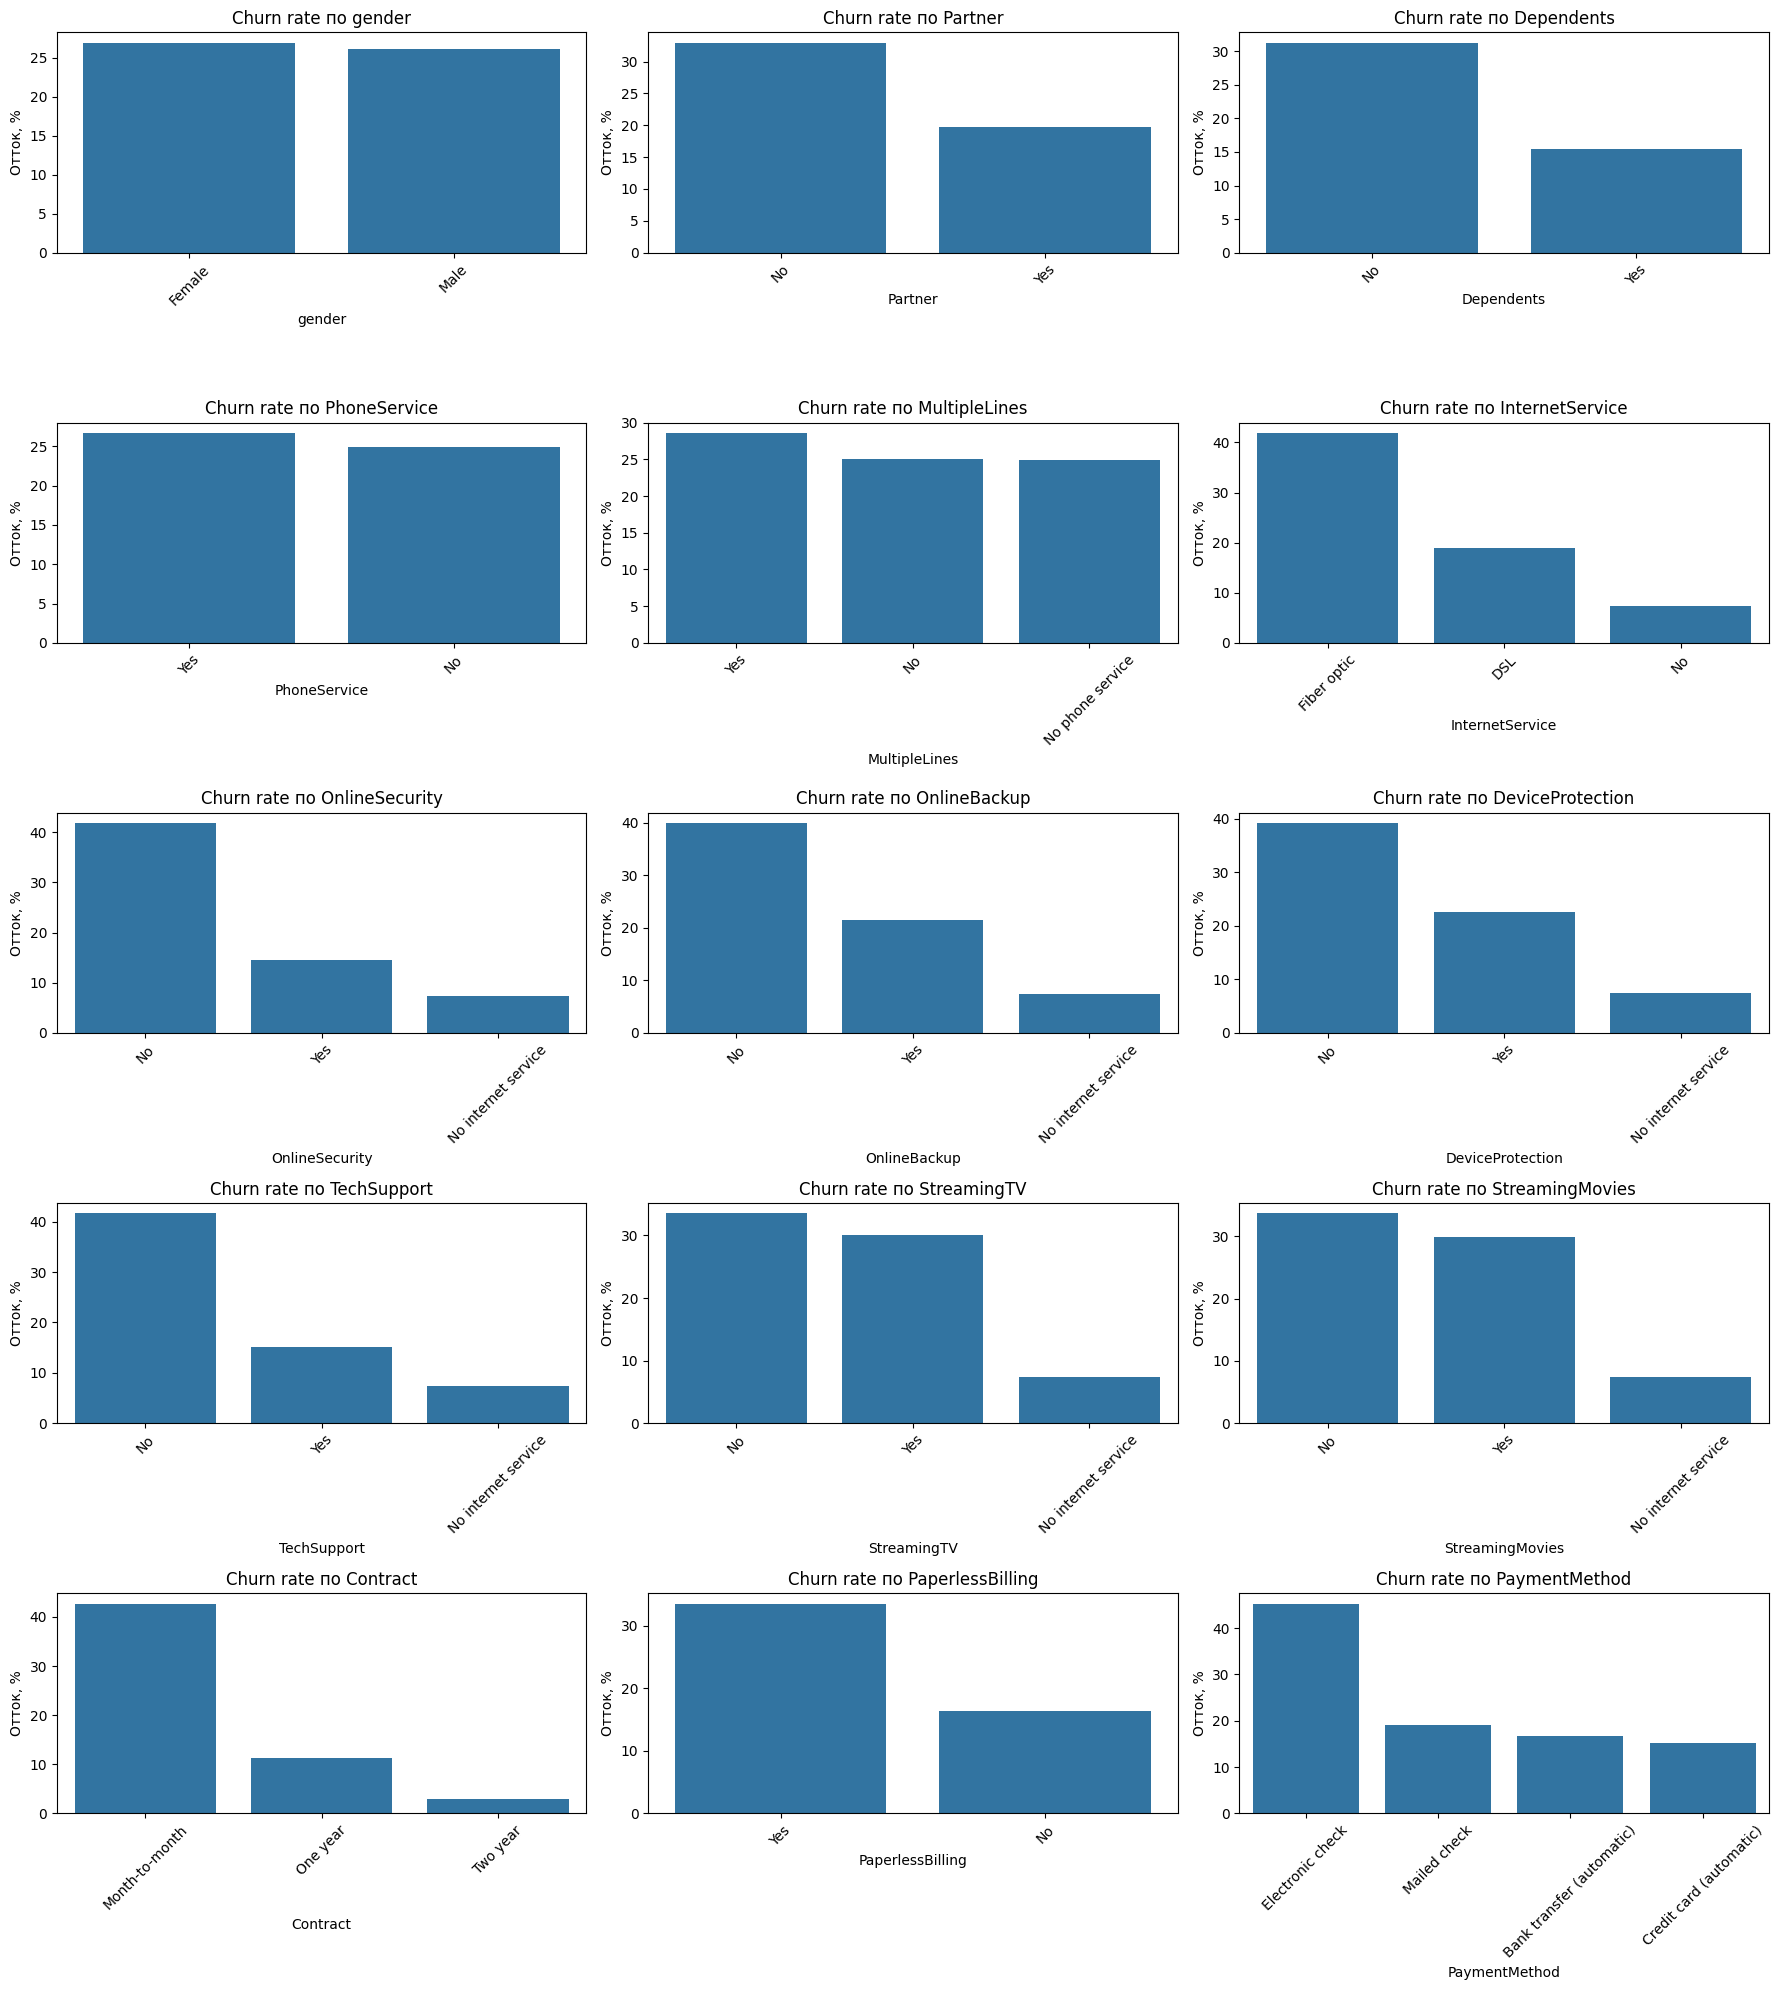

In [ ]:
cat_features = ['gender','Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
                'PaymentMethod']

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18, 20))
axes = axes.flatten()

for idx, col in enumerate(cat_features):
    churn_rate = data.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean() * 100).sort_values(ascending=False)
    sns.barplot(x=churn_rate.index, y=churn_rate.values, ax=axes[idx])
    axes[idx].set_title(f"Churn rate по {col}")
    axes[idx].set_ylabel("Отток, %")
    axes[idx].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Можно заметить что, если у пользователя no internet service, то в каждом признаке процент оттока меньше

Internetservice - отток fiber optic больше чем DSL в 2 раза

OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport отсутствие этих опций увеличивает процент оттока клиентов

Наиболее высокий отток у пользователей, заключающих ежемесячный договор

Также интересно что отток пользователей, оплачивающих электронным чеком в два раза выше по сравнении с остальными.

Также, если у пользователя есть иждивенец, то отток уменьшается почти в два раза

Наличие партрнера - отток выше в полтора раза

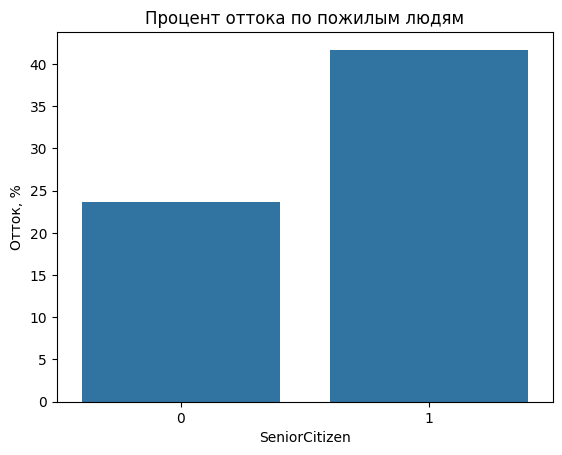

In [ ]:
churn_rate_SeniorCitizen = data.groupby("SeniorCitizen")["Churn"].apply(lambda x: (x == "Yes").mean() * 100).sort_values(ascending=False)
sns.barplot(x=churn_rate_SeniorCitizen.index, y=churn_rate_SeniorCitizen.values)
plt.title("Процент оттока по пожилым людям")
plt.ylabel("Отток, %")
plt.show()

Процент оттока у пожилых людей выше чем у не пожилых

Посмотрим распределение числовых признаков

<Axes: >

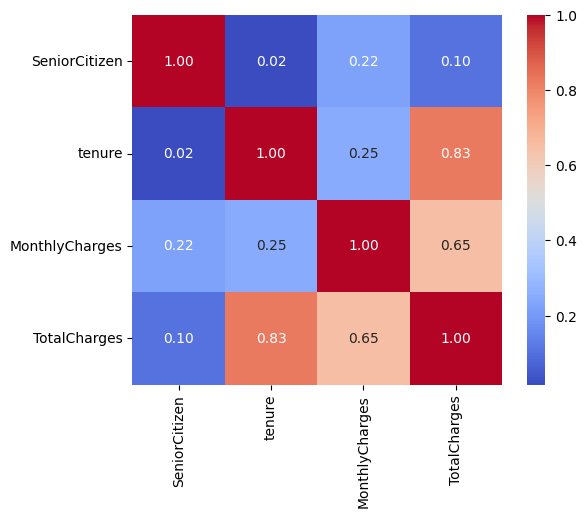

In [ ]:
numeric_cols = data.select_dtypes(include="number").columns.tolist()
corr = data[numeric_cols].corr()
sns.heatmap(corr,annot=True, cmap="coolwarm", fmt=".2f", square=True)

In [ ]:
numeric_features = data[['tenure', 'MonthlyCharges', 'TotalCharges']]
numeric_features = add_constant(numeric_features)

vif_data = pd.DataFrame()
vif_data["feature"] = numeric_features.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_features.values, i) for i in range(numeric_features.shape[1])]

print(vif_data)

          feature        VIF
0           const  14.897897
1          tenure   5.835936
2  MonthlyCharges   3.216590
3    TotalCharges   9.509815


TotalCharges, MonthlyCharges и tenure являются мультиколлиниарными признаками

Для TotalCharges VIF получился 9.5 что является признаком высокой мультиколлиниарности

При этом tenure умеренно колиниарен

TotalCharges = MothlyCharges * tenure

Удалим его позже

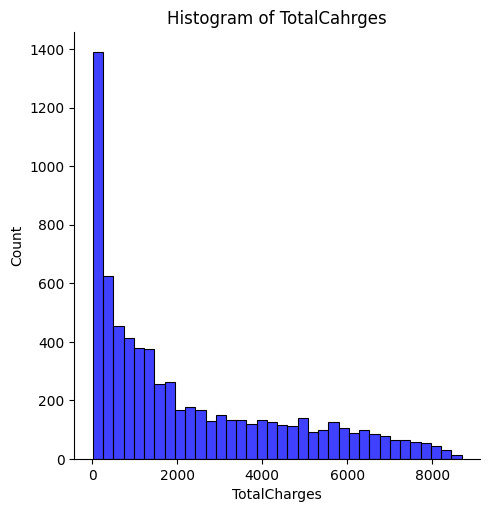

In [ ]:
sns.displot(data["TotalCharges"], kde=False,
             bins=int(180/5), color = 'blue')
plt.title('Histogram of TotalCahrges')
plt.show()

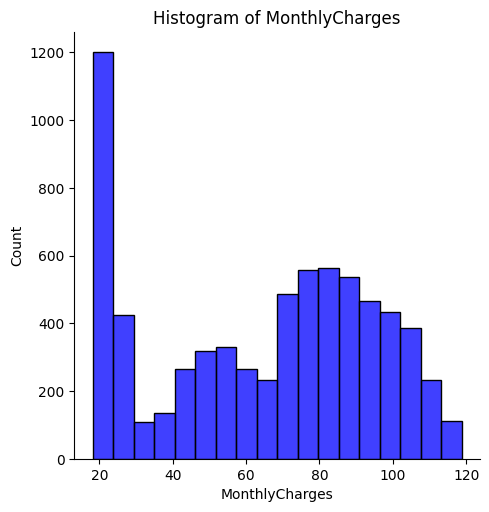

In [ ]:
sns.displot(data["MonthlyCharges"], kde=False, color = 'blue')
plt.title('Histogram of MonthlyCharges')
plt.show()

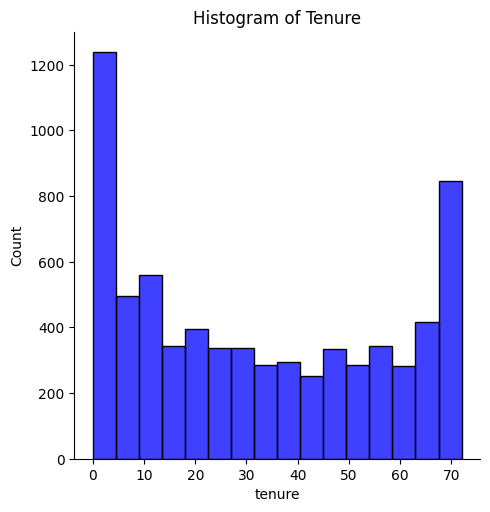

In [ ]:
sns.displot(data["tenure"], kde=False, color = 'blue')
plt.title('Histogram of Tenure')
plt.show()

In [ ]:
data.groupby("Churn")["TotalCharges"].std()

,TotalCharges
Churn,
No,2329.858843
Yes,1890.822994


In [ ]:
data.groupby("Churn")["MonthlyCharges"].std()

,MonthlyCharges
Churn,
No,31.092648
Yes,24.666053


Есть предположение, что признак MonthlyCharges и tenure влияет на целевую переменную

Проверим равенство распределений

H0 - распеределения равны, H1 - распределения отличаются, alpha = 0.05

In [ ]:
group_churn_no = data[data["Churn"] == "No"]["MonthlyCharges"]
group_churn_yes = data[data["Churn"] == "Yes"]["MonthlyCharges"]
u_stat, p_mw = mannwhitneyu(group_churn_no, group_churn_yes, alternative="two-sided")
print(f"U статистика: {u_stat:.1f}")
print(f"p-value: {p_mw:.6f}")
t_stat_welch, p_welch = ttest_ind(group_churn_no, group_churn_yes, equal_var=False)
print(f"Уэлч (неравные): p = {p_welch:.5f}")

U статистика: 3667080.5
p-value: 0.000000
Уэлч (неравные): p = 0.00000


Значит мы отвергаем H0, p-value в обоих тестах много меньше 0.05, что значит скорее всего это не случайность

Проверим насколько сильно они отличаются, строк много и небольшое отклонение может давать низкое p-value

In [ ]:
effect_size = 1 - (2 * u_stat) / (len(group_churn_no) * len(group_churn_yes))
print(f"Размер эффекта (V-статистика): {effect_size:.3f}")
median_no = group_churn_no.median()
median_yes = group_churn_yes.median()
print(f"Медиана TotalCharges для 'No': {median_no:.2f}")
print(f"Медиана TotalCharges для 'Yes': {median_yes:.2f}")
print(f"Абсолютная разница медиан: {abs(median_no - median_yes):.2f}")

Размер эффекта (V-статистика): 0.242
Медиана TotalCharges для 'No': 64.43
Медиана TotalCharges для 'Yes': 79.65
Абсолютная разница медиан: 15.22


Медианы отличаются, но не сильно, эффект умеренный

Проведем такие же тесты и для tenure(сколько месяцев клиент пользуется сервисом)

In [ ]:
group_churn_no = data[data["Churn"] == "No"]["tenure"]
group_churn_yes = data[data["Churn"] == "Yes"]["tenure"]
u_stat, p_mw = mannwhitneyu(group_churn_no, group_churn_yes, alternative="two-sided")
print(f"U статистика: {u_stat:.1f}")
print(f"p-value: {p_mw:.6f}")
t_stat_welch, p_welch = ttest_ind(group_churn_no, group_churn_yes, equal_var=False)
print(f"Уэлч (неравные): p = {p_welch:.5f}")

U статистика: 7154668.0
p-value: 0.000000
Уэлч (неравные): p = 0.00000


In [ ]:

effect_size = 1 - (2 * u_stat) / (len(group_churn_no) * len(group_churn_yes))
print(f"Размер эффекта (V-статистика): {effect_size:.3f}")

median_no = group_churn_no.median()
median_yes = group_churn_yes.median()
print(f"Медиана TotalCharges для 'No': {median_no:.2f}")
print(f"Медиана TotalCharges для 'Yes': {median_yes:.2f}")
print(f"Абсолютная разница медиан: {abs(median_no - median_yes):.2f}")

Размер эффекта (V-статистика): -0.480
Медиана TotalCharges для 'No': 38.00
Медиана TotalCharges для 'Yes': 10.00
Абсолютная разница медиан: 28.00


Так tenure оказывает больший эффект на целевую переменную, H0 также отвергается, причем разница медиан почти в три раза

Рассмотрим оба признака (MonthlyCharges и tenure) на выбросы

/tmp/ipykernel_1025/3340562954.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = data, x = "Churn",y = "MonthlyCharges", palette="Set2")


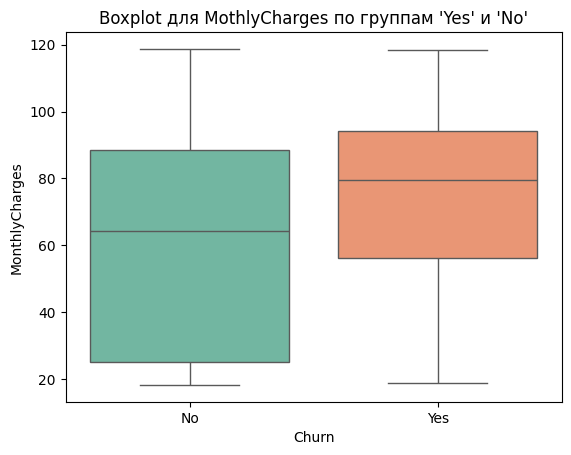

In [ ]:
sns.boxplot(data = data, x = "Churn",y = "MonthlyCharges", palette="Set2")
plt.title("Boxplot для MothlyCharges по группам 'Yes' и 'No'")
plt.show()

/tmp/ipykernel_1025/1690838882.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = data, x = "Churn",y = "tenure", palette="Set2")


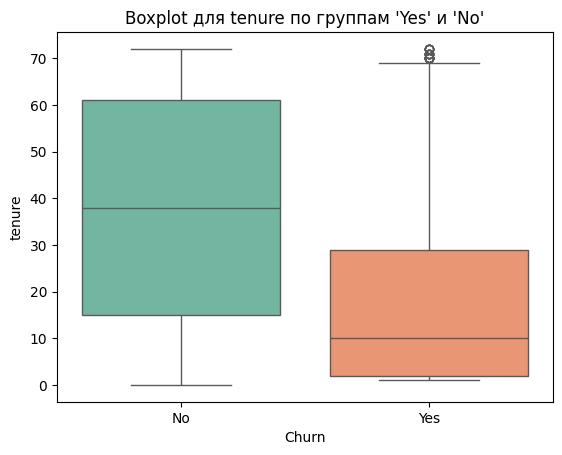

In [ ]:
sns.boxplot(data = data, x = "Churn",y = "tenure", palette="Set2")
plt.title("Boxplot для tenure по группам 'Yes' и 'No'")
plt.show()

Исходя из boxplot, можно заметить что в признаке tenure есть выбросы по группе yes, но не думаю что их стоит удалять

Посмотрим как изменяется отток клиентов с увеличением tenure

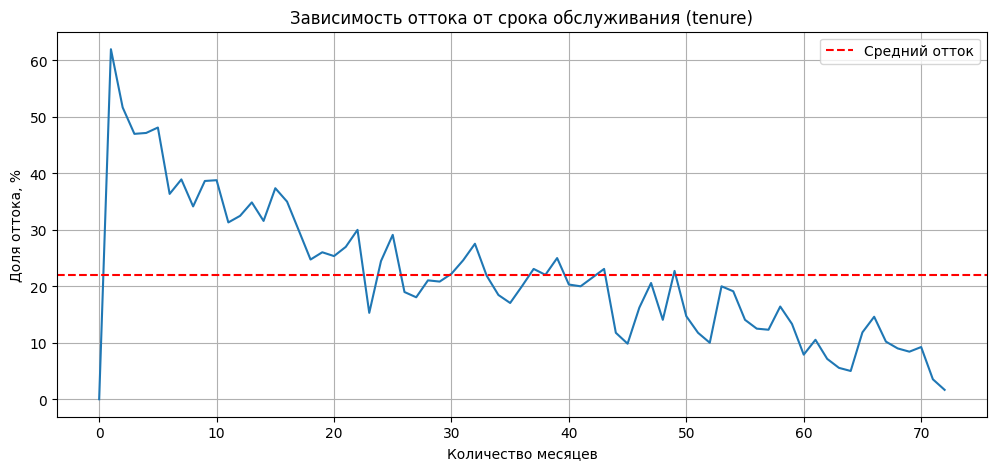

In [ ]:
churn_by_tenure = data.groupby("tenure")["Churn"].apply(lambda x: (x == "Yes").mean() * 100).reset_index()
plt.figure(figsize=(12,5))
sns.lineplot(data=churn_by_tenure, x="tenure", y="Churn")
plt.axhline(y=churn_by_tenure["Churn"].mean(), color="red", linestyle="--", label="Средний отток")
plt.title("Зависимость оттока от срока обслуживания (tenure)")
plt.xlabel("Количество месяцев")
plt.ylabel("Доля оттока, %")
plt.legend()
plt.grid(True)
plt.show()

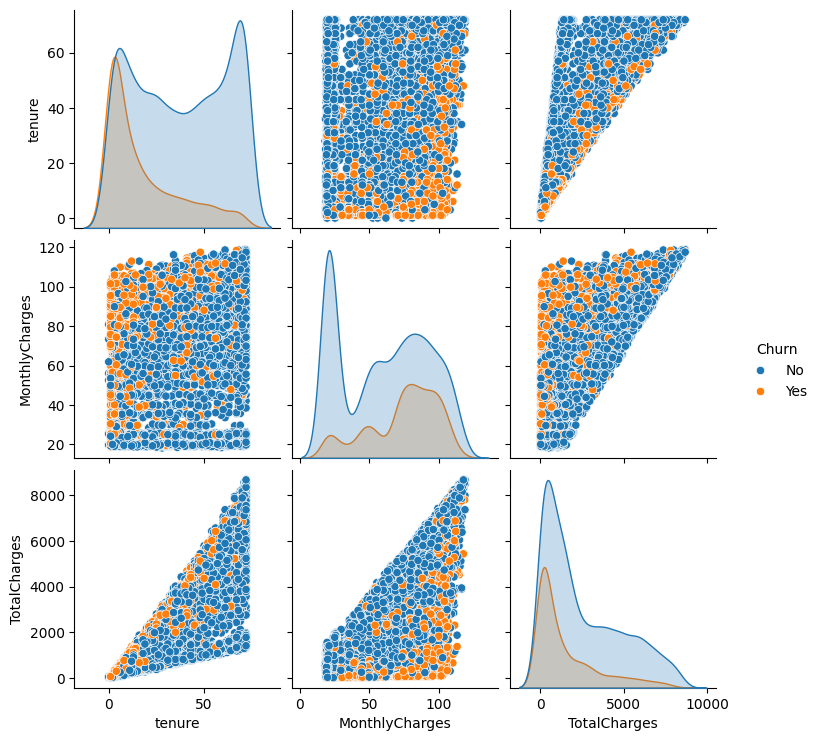

In [ ]:
sns.pairplot(data, hue="Churn", vars=["tenure", "MonthlyCharges", "TotalCharges"])
plt.show()

Исходя из pairplot, можно сделать вывод что если высокая ежемесечная плата в первые месяцы, то отток клиентов максимален

Удалим ненужные признаки и подготовим данные для входа моделей

In [ ]:
def target_encode(y):
  return (y == "Yes").astype(int)
def drop_columns(X):
    return X.drop(["customerID", "TotalCharges"], axis=1)
def log_transform(X):
    import pandas as pd
    result = np.log1p(X)
    if hasattr(X, 'columns'):
        return pd.DataFrame(result, columns=X.columns, index=X.index)
    return result
log_transformer = FunctionTransformer(np.log1p, validate=True, feature_names_out="one-to-one")
del multiclass_cols["TotalCharges"]
del multiclass_cols["customerID"]
binary_cols.remove("Churn")
numeric_cols = ["tenure", "MonthlyCharges"]
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("log",log_transformer),
            ("scaler", StandardScaler())
        ]), numeric_cols),

        ("cat_multi", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), list(multiclass_cols.keys())),
        ("cat_binary",Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("ordinal", OrdinalEncoder())
        ]),binary_cols)
    ]
)

In [ ]:
X = data.drop("Churn",axis = 1)
X = drop_columns(X)
y = target_encode(data["Churn"])

In [ ]:
X.shape

(7043, 18)

In [ ]:
def get_metrics(y_true, y_pred, y_proba, model_name):
    return {
        "Model": model_name,
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
        "F1-Score": f1_score(y_true, y_pred),
        "Recall": recall_score(y_true,y_pred),
        "Precision": precision_score(y_true,y_pred)
    }
results = []

#Обучение моделей

Главной метрикой будет recall

Сначала протестируем логистическую регрессию

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score,average_precision_score,f1_score
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,stratify = y,random_state = 42)
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")
lr.fit(X_train,y_train)
preds_lr = lr.predict(X_test)
preds_proba = lr.predict_proba(X_test)[:,1]
print(roc_auc_score(y_test,preds_proba))
print(average_precision_score(y_test,preds_proba))
print(f1_score(y_test,preds_lr))
print("Проверим на переобучение на трейне")
preds_lr_train = lr.predict(X_train)
preds_proba_train_lr = lr.predict_proba(X_train)[:,1]
print(roc_auc_score(y_train,preds_proba_train_lr))
print(average_precision_score(y_train,preds_proba_train_lr))
print(f1_score(y_train,preds_lr_train))

results.append(get_metrics(y_test, preds_lr, preds_proba, "LogisticRegresion"))

0.847043323258157
0.6641433016578734
0.6153846153846154
Проверим на переобучение на трейне
0.8537941968113086
0.6773505018726801
0.6401906274821286


#Посмотрим как справляется RandomForest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(class_weight="balanced")
rf.fit(X_train,y_train)
preds_rf = rf.predict(X_test)
preds_proba_rf = rf.predict_proba(X_test)[:,1]
print(roc_auc_score(y_test,preds_proba_rf))
print(average_precision_score(y_test,preds_proba_rf))
print(f1_score(y_test,preds_rf))
print("Проверим на переобучение на трейне")
preds_rf_train = rf.predict(X_train)
preds_proba_train_rf = rf.predict_proba(X_train)[:,1]
print(roc_auc_score(y_train,preds_proba_train_rf))
print(average_precision_score(y_train,preds_proba_train_rf))
print(f1_score(y_train,preds_rf_train))

0.8095688341212639
0.5814269120126526
0.5059880239520959
Проверим на переобучение на трейне
0.9997971817146791
0.9992825376457248
0.9943314438146049


Видим сильное переобучение у RandomForest, попробуем ограничить модель

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(max_depth = 10,min_samples_leaf = 15, class_weight="balanced")
rf.fit(X_train,y_train)
preds_rf = rf.predict(X_test)
preds_proba_rf = rf.predict_proba(X_test)[:,1]
print(roc_auc_score(y_test,preds_proba_rf))
print(average_precision_score(y_test,preds_proba_rf))
print(f1_score(y_test,preds_rf))
print("Проверим на переобучение на трейне")
preds_rf_train = rf.predict(X_train)
preds_proba_train_rf = rf.predict_proba(X_train)[:,1]
print(roc_auc_score(y_train,preds_proba_train_rf))
print(average_precision_score(y_train,preds_proba_train_rf))
print(f1_score(y_train,preds_rf_train))

results.append(get_metrics(y_test, preds_rf, preds_proba_rf, "RandomForest"))

0.8403949985791418
0.6390809550018922
0.6230936819172114
Проверим на переобучение на трейне
0.8815546061971894
0.7236281753598842
0.6684827022609643


In [ ]:
y_train.shape

(5634,)

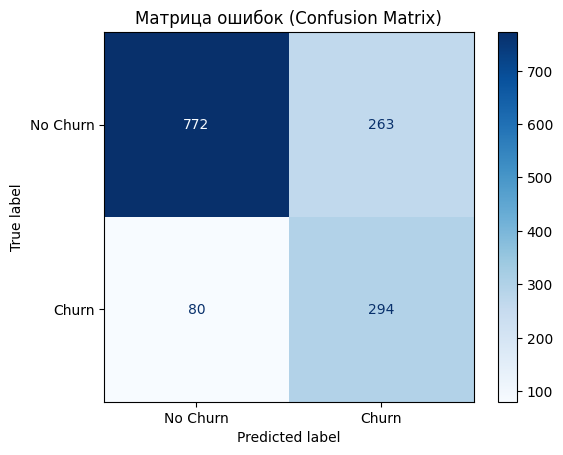

In [ ]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm = confusion_matrix(y_test, preds_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap=plt.cm.Blues)

plt.title('Матрица ошибок (Confusion Matrix)')
plt.show()

#Посмотрим на lightGBM

In [ ]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(
    objective='binary',
    metric='auc',
    class_weight='balanced',

    learning_rate=0.03,
    n_estimators=1000,

    max_depth=4,
    num_leaves=20,
    min_child_samples = 200,
    random_state=42
)
lgbm.fit(X_train,y_train)
preds_lgbm = lgbm.predict(X_test)
preds_proba_lgbm = lgbm.predict_proba(X_test)[:,1]
print(roc_auc_score(y_test,preds_proba_lgbm))
print(average_precision_score(y_test,preds_proba_lgbm))
print(f1_score(y_test,preds_lgbm))

results.append(get_metrics(y_test, preds_lgbm, preds_proba_lgbm, "LightGBM"))

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000844 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 401
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.8414683923635331
0.639923403823315
0.620021528525296


In [ ]:
preds_lgbm = lgbm.predict(X_train)
preds_proba_lgbm = lgbm.predict_proba(X_train)[:,1]
print(roc_auc_score(y_train,preds_proba_lgbm))
print(average_precision_score(y_train,preds_proba_lgbm))
print(f1_score(y_train,preds_lgbm))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.8970476606809683
0.7439004637165056
0.6957700650759219


#Посмотрим как справляется EasyEnsemble

In [ ]:
eec = EasyEnsembleClassifier(estimator=LogisticRegression(random_state=42, max_iter=1000),
    n_estimators=10,
    sampling_strategy='auto',
    random_state=42,
    n_jobs=-1
)

eec.fit(X_train, y_train)


y_pred = eec.predict(X_test)
y_proba = eec.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test,y_proba))
print(average_precision_score(y_test,y_proba))
print(f1_score(y_test,y_pred))

results.append(get_metrics(y_test, y_pred, y_proba, 'LogisticRegresion_EasyEnsemble'))

0.8470639902864968
0.6646555109271357
0.6161825726141079


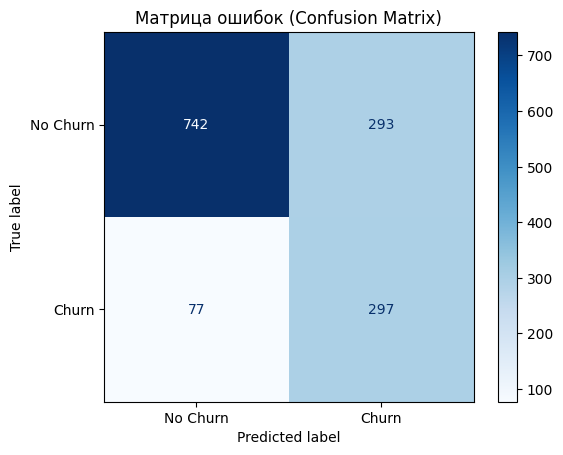

In [ ]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap=plt.cm.Blues)

plt.title('Матрица ошибок (Confusion Matrix)')
plt.show()

Выведем табличку с метриками по всем сделанным моделям

In [ ]:
results_df = pd.DataFrame(results)

for col in results_df.columns:
    if col != "Model":
        results_df[col] = results_df[col].map(lambda x: f"{x:.4f}")
results_df

,Model,ROC-AUC,PR-AUC,F1-Score,Recall,Precision
0,LogisticRegresion,0.8470,0.6641,0.6154,0.7914,0.5034
1,RandomForest,0.8404,0.6391,0.6231,0.7647,0.5257
2,LightGBM,0.8415,0.6399,0.6200,0.7701,0.5189
3,LogisticRegresion_EasyEnsemble,0.8471,0.6647,0.6162,0.7941,0.5034


Из таблицы видно что лучше всего справляется логистическая регрессия с EasyEnsemble

# В общем главные проблемы это мало данных и дисбаланс классов

Пойдем не через train_test_split, а через кросс-валидацию стратифицированную, возможно попробуем SMOTE(увеличит количество данных), возможно сделаем features selection через логистическую регрессию(хотя как бы признаков не так много, но и количество строк маловато)

In [ ]:
from sklearn.model_selection import StratifiedKFold
from imblearn.combine import SMOTETomek
from sklearn.base import clone
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
def evaluate_model_cv(X, y, model):
    auc_scores = []
    pr_auc_scores = []
    recall = []
    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        X_train = preprocessor.fit_transform(X_train)
        X_val = preprocessor.transform(X_val)
        smote = SMOTETomek(random_state=42, sampling_strategy='auto')
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
        model_copy = clone(model)
        model_copy.fit(X_train_res, y_train_res)
        y_proba = model_copy.predict_proba(X_val)[:, 1]
        y_pred = model_copy.predict(X_val)
        auc_scores.append(roc_auc_score(y_val, y_proba))
        pr_auc_scores.append(average_precision_score(y_val, y_proba))
        recall.append(recall_score(y_val,y_pred))
    return {
        'roc_auc_mean': np.mean(auc_scores),
        'roc_auc_std': np.std(auc_scores),
        'pr_auc_mean': np.mean(pr_auc_scores),
        'pr_auc_std': np.std(pr_auc_scores),
        "recall_mean": np.mean(recall),
        "recall_std": np.std(recall)
    }
model = LogisticRegression(class_weight='balanced', random_state=42)
results = evaluate_model_cv(X, y, model)
print(f"ROC-AUC: {results['roc_auc_mean']:.4f} (+/- {results['roc_auc_std']:.4f})")
print(f"PR-AUC: {results['pr_auc_mean']:.4f} (+/- {results['pr_auc_std']:.4f})")
print(f"Recall: {results['recall_mean']:.4f} (+/- {results['recall_std']:.4f})")

ROC-AUC: 0.8489 (+/- 0.0106)
PR-AUC: 0.6708 (+/- 0.0158)
Recall: 0.7940 (+/- 0.0171)


Попробуем сделать feature selection

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel

full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", SelectFromModel(
        LogisticRegression(penalty="l1", solver="liblinear", C=0.1, max_iter=1000,class_weight="balanced")
    )),
    ("classifier", LogisticRegression(max_iter=1000))
])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify= y, random_state=42)
full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('log',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>,
                                                                                       validate=True)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges']),
                                                 ('cat_multi',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strateg...
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder())]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'PaperlessBilling'])])),
                ('feature_selection',
                 SelectFromModel(estimator=LogisticRegression(C=0.1,
                                                              class_weight='balanced',
                                                              max_iter=1000,
                                                              penalty='l1',
                                                              solver='liblinear'))),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
selector = full_pipeline.named_steps["feature_selection"]
selected_mask = selector.get_support()
selected_features = feature_names[selected_mask]
estimator = selector.estimator_
coefficients = estimator.coef_[0]
selected_coefficients = coefficients[selected_mask]
print("\nКоэффициенты отобранных признаков:")
for name, coef in zip(selected_features, selected_coefficients):
    print(f"{name}: {coef:.4f}")


Коэффициенты отобранных признаков:
num__tenure: -0.7661
num__MonthlyCharges: 0.7608
cat_multi__MultipleLines_No: -0.2553
cat_multi__InternetService_DSL: -0.2290
cat_multi__InternetService_Fiber optic: 0.2281
cat_multi__OnlineSecurity_Yes: -0.4227
cat_multi__OnlineBackup_No: 0.0452
cat_multi__OnlineBackup_Yes: -0.1338
cat_multi__DeviceProtection_Yes: -0.0207
cat_multi__TechSupport_No: 0.1206
cat_multi__TechSupport_Yes: -0.2254
cat_multi__StreamingTV_No: -0.0696
cat_multi__StreamingMovies_No: -0.0909
cat_multi__Contract_Month-to-month: 0.6746
cat_multi__Contract_Two year: -0.8890
cat_multi__PaymentMethod_Electronic check: 0.3556
cat_multi__PaymentMethod_Mailed check: -0.0091
cat_binary__Dependents: -0.1889
cat_binary__PhoneService: -0.7149
cat_binary__PaperlessBilling: 0.2957


In [ ]:
y_pred = full_pipeline.predict(X_test)
y_pred_proba = full_pipeline.predict_proba(X_test)[:,1]
print(roc_auc_score(y_test, y_pred_proba))
print(average_precision_score(y_test, y_pred))

0.8471737838745512
0.4823907363634912


Попробуем подобрать гиперпараметры, используем SMOTE и подбираем гиперпараметры на отобранных признаках

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,stratify = y,random_state = 42)
pipe = ImbPipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", SelectFromModel(
        LogisticRegression(penalty="l1", solver="liblinear", C=0.1,
                          max_iter=1000, class_weight="balanced")
    )),
    ("smote", SMOTETomek(random_state=42,sampling_strategy="auto")),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42))
])

param_grid = {
    "classifier__max_depth": [5, 7, 10],
    "classifier__min_samples_leaf": [5, 10, 20],
    "classifier__max_features": [0.3, 0.5, 0.7],
    "classifier__n_estimators": [100, 200],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучший ROC-AUC (cv):", grid_search.best_score_)

y_pred = grid_search.predict(X_test)
y_proba = grid_search.predict_proba(X_test)[:, 1]
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test PR-AUC:", average_precision_score(y_test, y_proba))
print("Recall:", recall_score(y_test,y_pred))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Лучшие параметры: {'classifier__max_depth': 7, 'classifier__max_features': 0.3, 'classifier__min_samples_leaf': 20, 'classifier__n_estimators': 200}
Лучший ROC-AUC (cv): 0.8440371822213517
Test ROC-AUC: 0.8401870366064739
Test PR-AUC: 0.6365410077144767
Recall: 0.7887700534759359


In [ ]:
pipe = ImbPipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", SelectFromModel(
        LogisticRegression(penalty="l1", solver="liblinear", C=0.1,
                          max_iter=1000, class_weight="balanced")
    )),
    ("smote", SMOTETomek(random_state=42,sampling_strategy="auto")),
    ("classifier", LGBMClassifier(random_state=42,class_weight = "balanced"))
])
lgb_param_dist = {
    'classifier__n_estimators': [200,300,400,500,1000,1200,1500],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__num_leaves':[5,7,10,12,15],
    'classifier__max_depth': [-1, 3, 5, 7, 10],
    'classifier__min_child_samples':[5,10,15,20],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_lgb = RandomizedSearchCV(
    pipe,
    param_distributions=lgb_param_dist,
    n_iter=100,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_search_lgb.fit(X_train, y_train)

print("Лучшие параметры:", random_search_lgb.best_params_)
print("Лучший ROC-AUC (cv):", random_search_lgb.best_score_)


y_pred = random_search_lgb.predict(X_test)
y_proba = random_search_lgb.predict_proba(X_test)[:, 1]
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test PR-AUC:", average_precision_score(y_test, y_proba))
print("Recall:", recall_score(y_test,y_pred))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[LightGBM] [Info] Number of positive: 3873, number of negative: 3873
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002706 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1825
[LightGBM] [Info] Number of data points in the train set: 7746, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Лучшие параметры: {'classifier__subsample': 0.8, 'classifier__num_leaves': 5, 'classifier__n_estimators': 1200, 'classifier__min_child_samples': 10, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.6}
Лучший ROC-AUC (cv): 0.8472483126133096
Test ROC-AUC: 0.8414645172957194
Test PR-AUC: 0.6510502930672355
Recall: 0.732620320855615


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Делаем ансамбль моделей

In [ ]:
best_lr = LogisticRegression(
    max_iter=1000, class_weight="balanced", random_state=42, C =0.1
)
best_rf = RandomForestClassifier(
    max_depth = 7, max_features = 0.5, min_samples_leaf =10, n_estimators =100,
    class_weight="balanced", random_state=42
)
best_lgbm = LGBMClassifier(
    objective='binary', class_weight='balanced',
    subsample =1.0, num_leaves = 12, n_estimators =500,
    min_child_samples =10, max_depth =-1, learning_rate = 0.01,
    colsample_bytree =0.6, random_state=42
)


voting = VotingClassifier(
    estimators=[
        ("lr", best_lr),
        ("rf", best_rf),
        ("lgbm", best_lgbm)
    ],
    voting="soft",
    n_jobs=-1
)

ensemble_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("feature_selection", SelectFromModel(
        LogisticRegression(penalty="l1", solver="liblinear", C=0.1,
                          max_iter=1000, class_weight="balanced")
    )),
    ("smote", SMOTE(random_state=42)),
    ("classifier", voting)
])

ensemble_pipeline.fit(X_train, y_train)

y_pred = ensemble_pipeline.predict(X_test)
y_proba = ensemble_pipeline.predict_proba(X_test)[:, 1]
print("Ensemble ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Ensemble PR-AUC:", average_precision_score(y_test, y_proba))
print("Recall:", recall_score(y_test,y_pred))

results.append(get_metrics(y_test, y_pred, y_proba, 'Ensemble'))

Ensemble ROC-AUC: 0.8452000826681132
Ensemble PR-AUC: 0.6554333137713373
Recall: 0.7620320855614974


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
results_df = pd.DataFrame(results)

for col in results_df.columns:
    if col != "Model":
        results_df[col] = results_df[col].map(lambda x: f"{x:.4f}")
results_df

,Model,ROC-AUC,PR-AUC,F1-Score,Recall,Precision
0,LogisticRegresion,0.8470,0.6641,0.6154,0.7914,0.5034
1,RandomForest,0.8404,0.6391,0.6231,0.7647,0.5257
2,LightGBM,0.8415,0.6399,0.6200,0.7701,0.5189
3,LogisticRegresion_EasyEnsemble,0.8471,0.6647,0.6162,0.7941,0.5034
4,Ensemble,0.8453,0.6546,0.6365,0.7701,0.5424


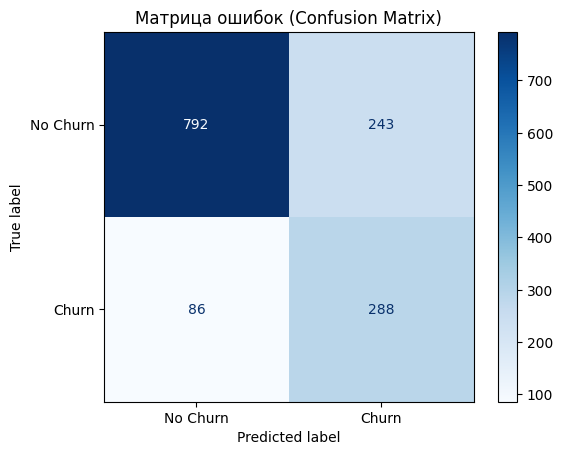

In [ ]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap=plt.cm.Blues)

plt.title('Матрица ошибок (Confusion Matrix)')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Лучший порог: 0.363
F1 при этом пороге: 0.6403


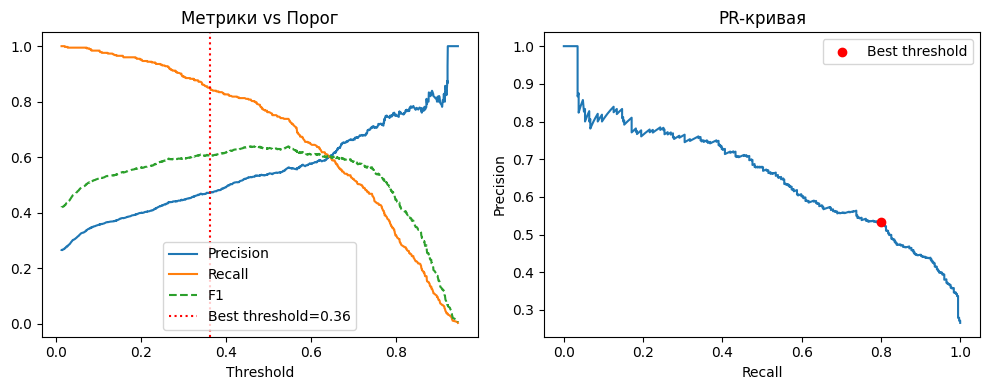

              precision    recall  f1-score   support

    No Churn       0.92      0.66      0.77      1035
       Churn       0.47      0.85      0.61       374

    accuracy                           0.71      1409
   macro avg       0.70      0.75      0.69      1409
weighted avg       0.80      0.71      0.73      1409



In [ ]:

y_proba = ensemble_pipeline.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold_idx = f1_scores.argmax()
target_recall = 0.85
valid_mask = recalls[:-1] >= target_recall
best_threshold = thresholds[valid_mask][precisions[:-1][valid_mask].argmax()]
print(f"Лучший порог: {best_threshold:.3f}")
print(f"F1 при этом пороге: {f1_scores[best_threshold_idx]:.4f}")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1_scores[:-1], label="F1", linestyle="--")
plt.axvline(best_threshold, color="red", linestyle=":", label=f"Best threshold={best_threshold:.2f}")
plt.xlabel("Threshold")
plt.legend()
plt.title("Метрики vs Порог")

plt.subplot(1, 2, 2)
plt.plot(recalls, precisions)
plt.scatter(recalls[best_threshold_idx], precisions[best_threshold_idx],
            color="red", zorder=5, label=f"Best threshold")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR-кривая")
plt.legend()

plt.tight_layout()
plt.show()

y_pred_custom = (y_proba >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_custom, target_names=["No Churn", "Churn"]))

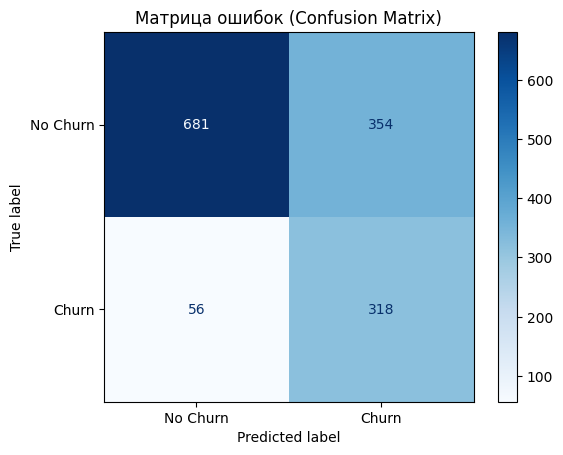

In [ ]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_custom)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap=plt.cm.Blues)

plt.title('Матрица ошибок (Confusion Matrix)')
plt.show()

Лучший порог: 0.425
F1 при этом пороге: 0.6403


/tmp/ipykernel_1025/3014128077.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


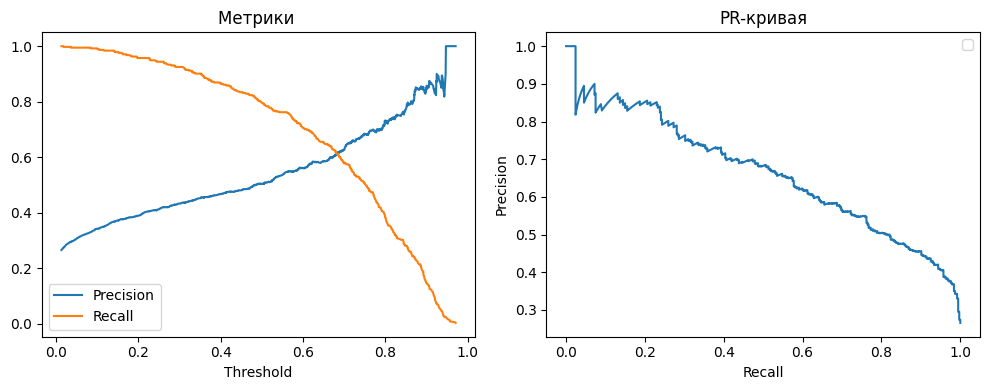

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,stratify = y,random_state = 42)
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)
eec = EasyEnsembleClassifier(estimator=LogisticRegression(random_state=42, max_iter=1000),
    n_estimators=10,
    sampling_strategy='auto',
    random_state=42,
    n_jobs=-1
)

eec.fit(X_train, y_train)


y_pred = eec.predict(X_test)
y_proba = eec.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

print(f"Лучший порог: {best_threshold:.3f}")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.title("Метрики ")

plt.subplot(1, 2, 2)
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR-кривая")
plt.legend()

plt.tight_layout()
plt.show()

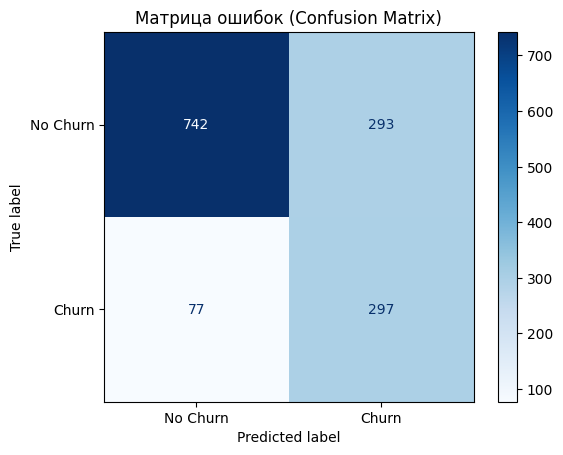

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap=plt.cm.Blues)

plt.title('Матрица ошибок (Confusion Matrix)')
plt.show()

#Вывод
Получили две модели: EasyEnsemble с логистической регрессией и ансамбль трех моделей

Что лучше?

Зависит от того что дешевле, если удержание клиента дорогое, то выигрывает ансамбль моделей. Однако, если удержать клиента дешевле, чем его потерять, то тогда выигрывает EasyEnsemble

Насчет порога. При изменении порога очень сильно увеличивается FP, при этом TP увеличивается несильно.

Главный вопрос в том, насколько важно сохранить клиента и насколько при этом можно увеличить долю ложных срабатываний